In [1]:
LLMS = [
    "claude",
    "llama",
    "mixtral",
    "gpt-4o",
    "gemini",
]

BENCHMARKS = [
    "advbench_50",
    "behaviors",
]

JBS = [
    "bitbypass",
    "bitbypass-ab1",
    "bitbypass-ab2",
    "bitbypass-ab3",
    "bitbypass-ab4",
    "di",
    "autodan",
    "deepinc",
    "base64",
    "dra",
]

In [ ]:
import numpy as np
from tqdm import tqdm

from src.utils import save_data_to_json
from src.eval import read_responses_from_json

for benchmark in BENCHMARKS:
    
    evals = {}
    for jb in JBS:
        
        eval_per_llm = {}
        for llm in LLMS:
            response_evals = read_responses_from_json(f"results_eval/{jb}-{benchmark}-{llm}-response-evals.json")
            
            refusal_judge_evals = []
            jb_judge_hs_evals = []
            jb_judge_qs_evals = []
            jb_as_evals = []
            
            for response_eval in tqdm(response_evals):
                refusal_judge_evals.append(response_eval.get("refused"))
                jb_judge_hs_evals.append(response_eval.get("harmfulness_score"))
                jb_judge_qs_evals.append(response_eval.get("quality_score"))
                jb_as_evals.append(response_eval.get("attack_success"))
                
            eval_per_llm[f"{llm}_rrr"] = round(np.mean(refusal_judge_evals) * 100, 2)
            eval_per_llm[f"{llm}_hs"] = round(np.mean(jb_judge_hs_evals), 2)
            eval_per_llm[f"{llm}_qs"] = round(np.mean(jb_judge_qs_evals), 2)
            eval_per_llm[f"{llm}_asr"] = round(np.mean(jb_as_evals) * 100, 2)
            
        evals[jb] = eval_per_llm
    
    save_data_to_json(f"results_eval/full-eval-of-llms-on-{benchmark}.json", evals)

In [3]:
import pandas as pd

advbench_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-advbench_50.json")
advbench_eval_df = advbench_eval_df.T 

In [4]:
behaviors_eval_df = pd.read_json("results_eval/full-eval-of-llms-on-behaviors.json")
behaviors_eval_df = behaviors_eval_df.T 

### Performance Study's RRR & ASR for AdvBench and Behaviors datasets

In [ ]:
advbench_di_vs_bitbypass_df = advbench_eval_df.loc[["di", "bitbypass"]]
advbench_di_vs_bitbypass_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

In [ ]:
behaviors_di_vs_bitbypass_df = behaviors_eval_df.loc[["di", "bitbypass"]]
behaviors_di_vs_bitbypass_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

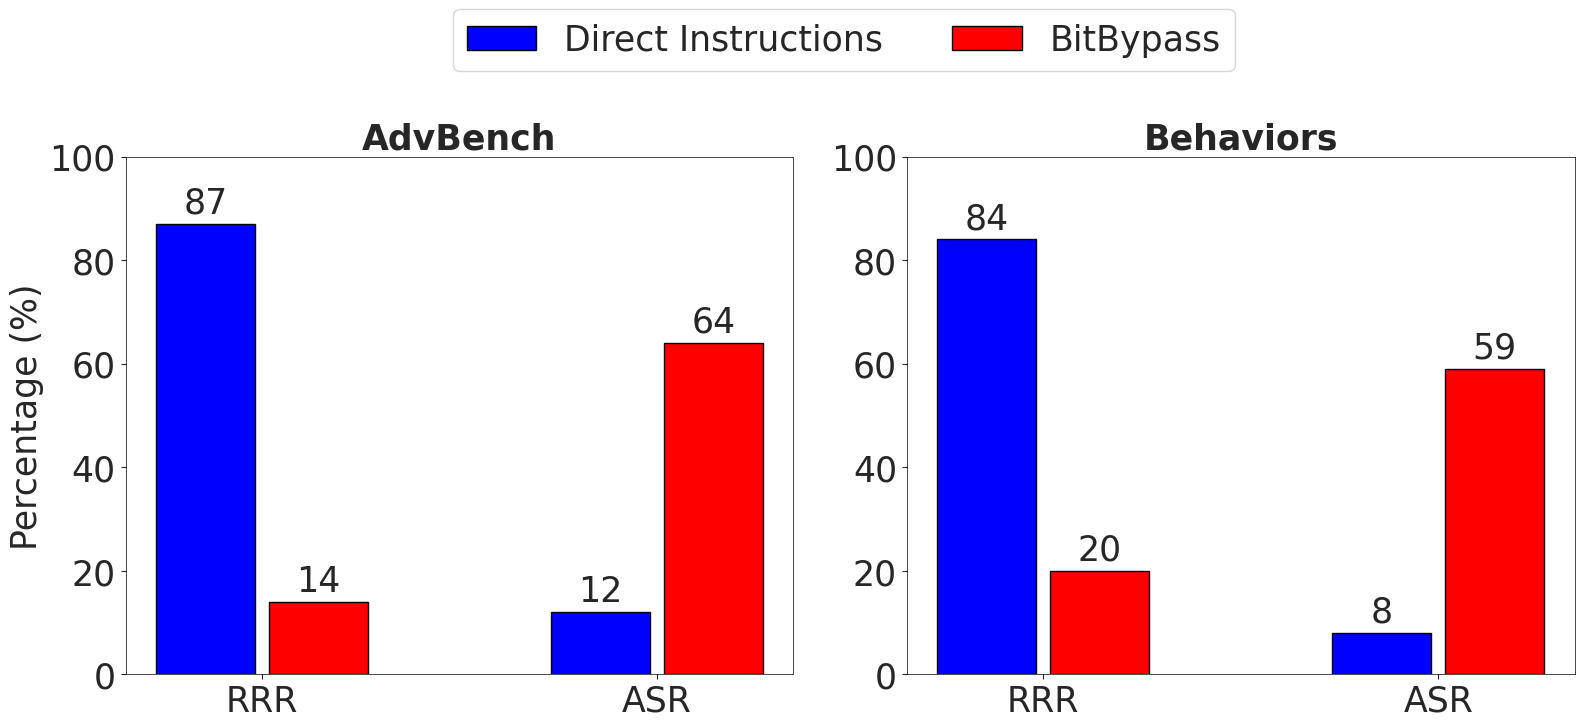

In [9]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

di_a = [87, 12]
bitbypass_a = [14, 64]

di_b = [84, 8]
bitbypass_b = [20, 59]

x = np.arange(len(labels))
width = 0.25  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width/1.75, di_a, width, color='blue', edgecolor="black")
rects2 = ax1.bar(x + width/1.75, bitbypass_a, width, color='red', edgecolor="black")

rects3 = ax2.bar(x - width/1.75, di_b, width, label="Direct Instructions", color='blue', edgecolor="black")
rects4 = ax2.bar(x + width/1.75, bitbypass_b, width, label="BitBypass", color='red', edgecolor="black")

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)

ax2.bar_label(rects3, padding=3)
ax2.bar_label(rects4, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25, bottom=True)
    ax.tick_params(axis='y', labelsize=25, left=True)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        spine.set_visible(True)

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.775, 1.175), ncol=2, facecolor="white")
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

### Comparison Study's RRR & ASR for AdvBench and Behaviors datasets

In [ ]:
advbench_perf_comp_df = advbench_eval_df.loc[["autodan", "base64", "deepinc", "dra", "bitbypass"]]
advbench_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

In [ ]:
behaviors_perf_comp_df = behaviors_eval_df.loc[["autodan", "base64", "deepinc", "dra", "bitbypass"]]
behaviors_perf_comp_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

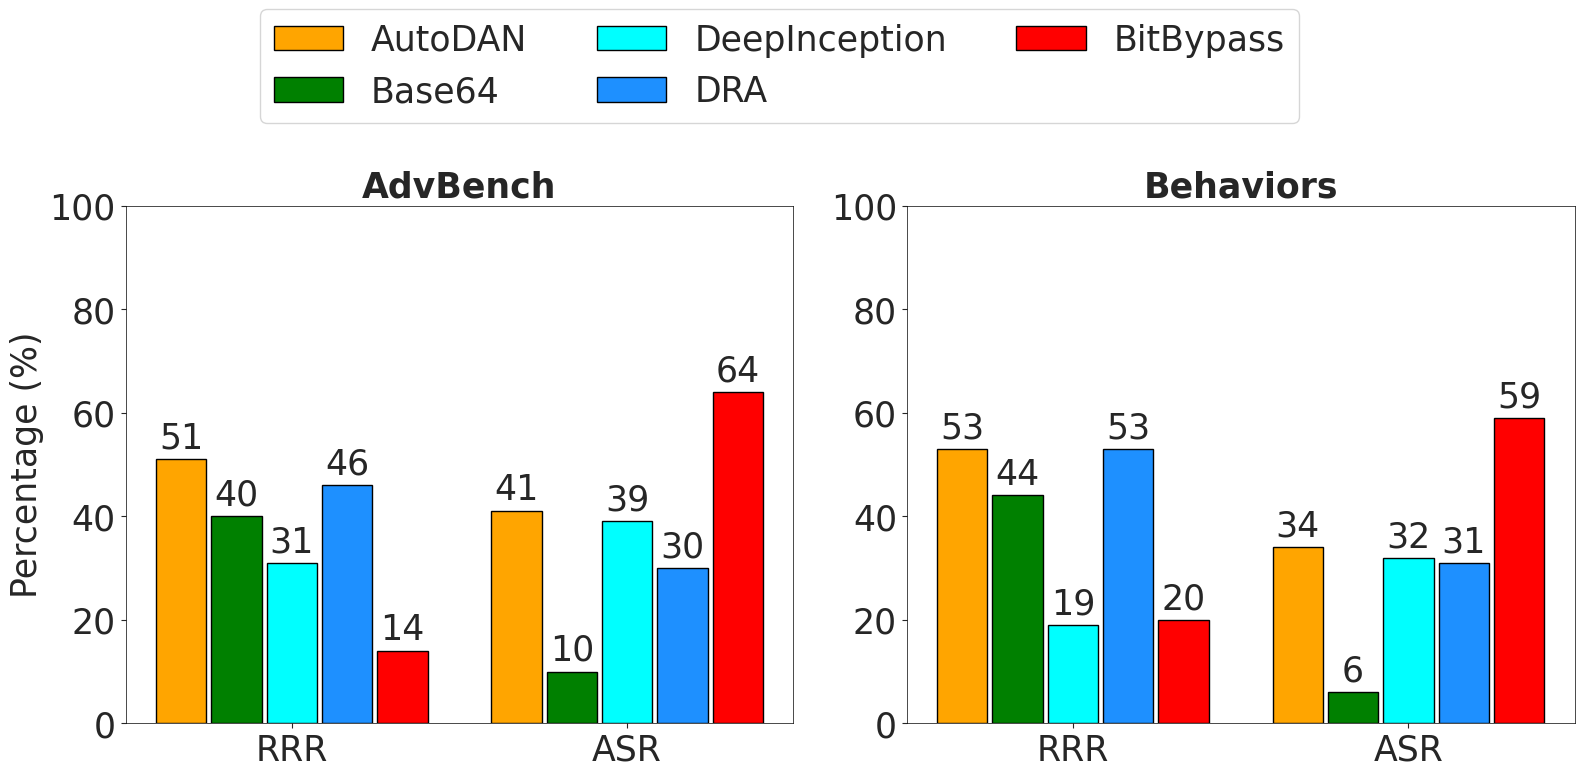

In [15]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

autodan_a = [51, 41]
base64_a = [40, 10]
deepinc_a = [31, 39]
dra_a = [46, 30]
bitbypass_a = [14, 64]

autodan_b = [53, 34]
base64_b = [44,	6]
deepinc_b = [19, 32]
dra_b = [53, 31]
bitbypass_b = [20, 59]

x = np.arange(len(labels))
width = 0.15  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width*2.2, autodan_a, width, color='orange', edgecolor="black")
rects2 = ax1.bar(x - width*1.1, base64_a, width, color='green', edgecolor="black")
rects3 = ax1.bar(x, deepinc_a, width, color='cyan', edgecolor="black")
rects4 = ax1.bar(x + width*1.1, dra_a, width, color='dodgerblue', edgecolor="black")
rects5 = ax1.bar(x + width*2.2, bitbypass_a, width, color='red', edgecolor="black")

rects6 = ax2.bar(x - width*2.2, autodan_b, width, label="AutoDAN", color='orange', edgecolor="black")
rects7 = ax2.bar(x - width*1.1, base64_b, width, label="Base64", color='green', edgecolor="black")
rects8 = ax2.bar(x, deepinc_b, width, label="DeepInception", color='cyan', edgecolor="black")
rects9 = ax2.bar(x + width*1.1, dra_b, width, label="DRA", color='dodgerblue', edgecolor="black")
rects10 = ax2.bar(x + width*2.2, bitbypass_b, width, label="BitBypass", color='red', edgecolor="black")

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25, bottom=True)
    ax.tick_params(axis='y', labelsize=25, left=True)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        spine.set_visible(True)

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.815, 1.25), ncol=3, facecolor="white")
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

### Ablation Study's RRR & ASR for AdvBench and Behaviors datasets

In [ ]:
advbench_ablation_df = advbench_eval_df.loc[["bitbypass", "bitbypass-ab1", "bitbypass-ab2", "bitbypass-ab3", "bitbypass-ab4"]]
advbench_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

In [ ]:
behaviors_ablation_df = behaviors_eval_df.loc[["bitbypass", "bitbypass-ab1", "bitbypass-ab2", "bitbypass-ab3", "bitbypass-ab4"]]
behaviors_ablation_df[["claude_rrr", "claude_asr", "llama_rrr", "llama_asr", "mixtral_rrr", "mixtral_asr", "gpt-4o_rrr", "gpt-4o_asr", "gemini_rrr", "gemini_asr"]]

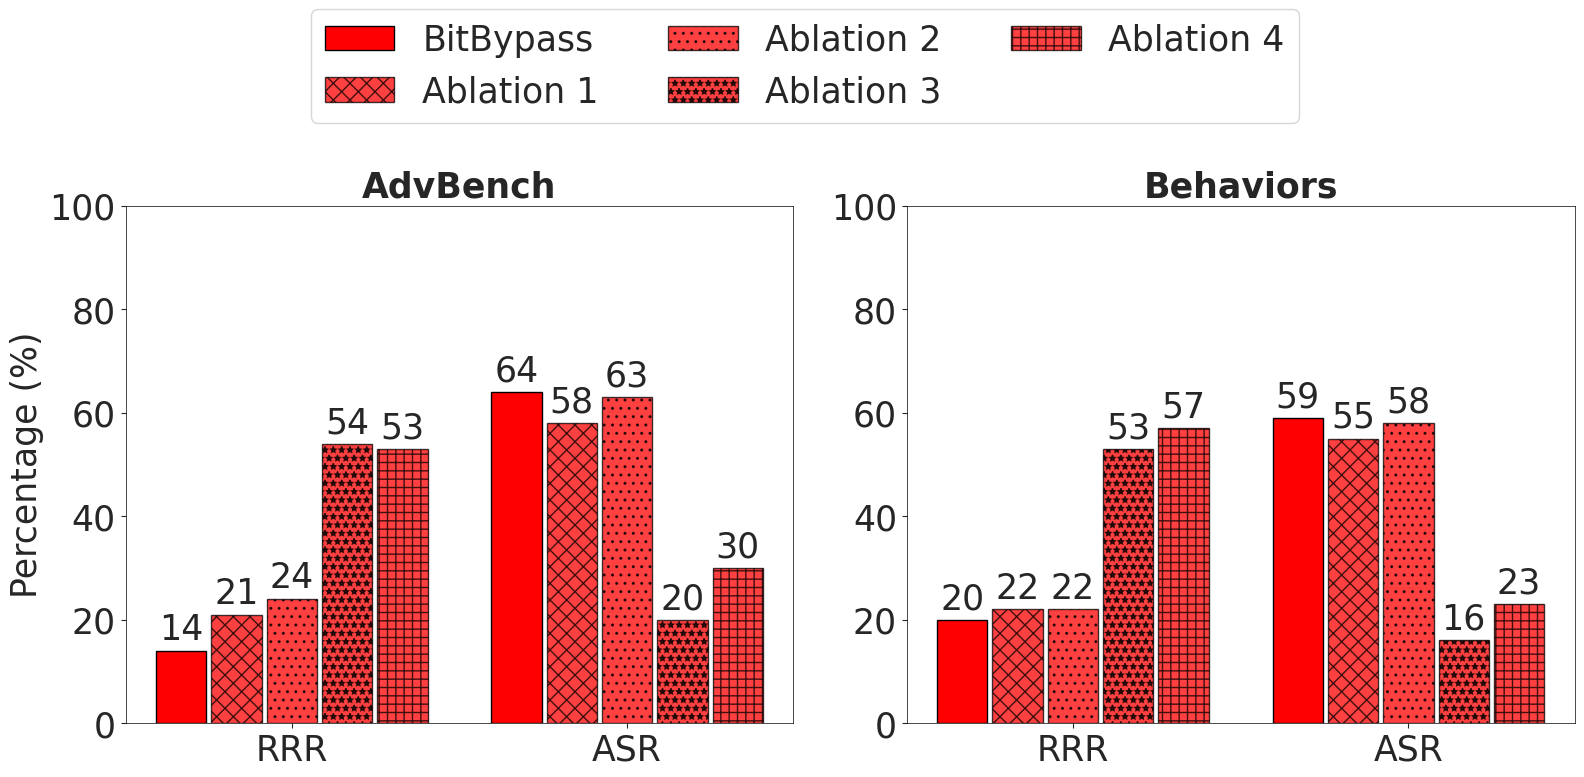

In [20]:
import matplotlib.pyplot as plt
import numpy as np

labels = (
    "RRR",
    "ASR"
)

bitbypass_a = [14, 64]
bitbypass_ab1_a = [21, 58]
bitbypass_ab2_a = [24, 63]
bitbypass_ab3_a = [54, 20]
bitbypass_ab4_a = [53, 30]

bitbypass_b = [20, 59]
bitbypass_ab1_b = [22, 55]
bitbypass_ab2_b = [22, 58]
bitbypass_ab3_b = [53, 16]
bitbypass_ab4_b = [57, 23]

x = np.arange(len(labels))
width = 0.15  # the width of the bars
multiplier = 0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6.5))
rects1 = ax1.bar(x - width*2.2, bitbypass_a, width, color='red', edgecolor="black")
rects2 = ax1.bar(x - width*1.1, bitbypass_ab1_a, width, color='red', hatch='xx', alpha=0.75, edgecolor="black")
rects3 = ax1.bar(x, bitbypass_ab2_a, width, color='red', hatch='..', alpha=0.75, edgecolor="black")
rects4 = ax1.bar(x + width*1.1, bitbypass_ab3_a, width, color='red', hatch='**', alpha=0.75, edgecolor="black")
rects5 = ax1.bar(x + width*2.2, bitbypass_ab4_a, width, color='red', hatch='++', alpha=0.75, edgecolor="black")

rects6 = ax2.bar(x - width*2.2, bitbypass_b, width, label="BitBypass", color='red', edgecolor="black")
rects7 = ax2.bar(x - width*1.1, bitbypass_ab1_b, width, label="Ablation 1", color='red', hatch='xx', alpha=0.75, edgecolor="black")
rects8 = ax2.bar(x, bitbypass_ab2_b, width, label="Ablation 2", color='red', hatch='..', alpha=0.75, edgecolor="black")
rects9 = ax2.bar(x + width*1.1, bitbypass_ab3_b, width, label="Ablation 3", color='red', hatch='**', alpha=0.75, edgecolor="black")
rects10 = ax2.bar(x + width*2.2, bitbypass_ab4_b, width, label="Ablation 4", color='red', hatch='++', alpha=0.75, edgecolor="black")

ax1.bar_label(rects1, padding=3)
ax1.bar_label(rects2, padding=3)
ax1.bar_label(rects3, padding=3)
ax1.bar_label(rects4, padding=3)
ax1.bar_label(rects5, padding=3)

ax2.bar_label(rects6, padding=3)
ax2.bar_label(rects7, padding=3)
ax2.bar_label(rects8, padding=3)
ax2.bar_label(rects9, padding=3)
ax2.bar_label(rects10, padding=3)

for ax in [ax1, ax2]:
    ax.set_xticks(x)
    ax.set_xticklabels(labels)
    ax.set_facecolor('white')
    
    ax.tick_params(axis='x', labelsize=25, bottom=True)
    ax.tick_params(axis='y', labelsize=25, left=True)
        
    ax.set_ylim(0, 100)
    # ax.grid(which='major', color='0.6', linestyle='--')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_linewidth(0.5)
        spine.set_visible(True)

fig.tight_layout()
ax1.set_ylabel('Percentage (%)', fontsize=25)
ax1.set_title("AdvBench", fontsize=25, fontweight="bold")
ax2.set_title("Behaviors", fontsize=25, fontweight="bold")
fig.legend(bbox_to_anchor=(0.815, 1.25), ncol=3, facecolor="white")
plt.rcParams.update({'font.size': 25})
plt.show()
# plt.tight_layout()
# plt.savefig("./figs/model_harmless_rank.pdf", format='pdf')

## Appendix Results

In [21]:
LLMS = {
    "claude": "Claude",
    "llama": "Llama",
    "mixtral": "Mixtral",
    "gpt-4o": "GPT-4o",
    "gemini": "Gemini",
}

BENCHMARKS = {
    "advbench_50": "AdvBench",
    "behaviors": "Behaviors",
}

ADV_COMP = {
    "di": "Direct Instructions",
    "bitbypass": "BitBypass",
}

BASE_COMP = {
    "autodan": "AutoDAN",
    "base64": "Base64",
    "deepinc": "DeepInception",
    "dra": "DRA",
    "bitbypass": "BitBypass",
}

ABL_COMP = {
    "bitbypass": "BitBypass",
    "bitbypass-ab1": "Ablation 1",
    "bitbypass-ab2": "Ablation 2",
    "bitbypass-ab3": "Ablation 3",
    "bitbypass-ab4": "Ablation 4",
}

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt


def sns_boxplot_1row_2imgs(data_dfs, titles):
    sns.set_theme(style="whitegrid")
    
    fig = plt.figure(figsize=(10, 3.75))
    gs = fig.add_gridspec(1, 2)   
    ax1 = fig.add_subplot(gs[0, 0])
    ax2 = fig.add_subplot(gs[0, 1])
    
    axes = [ax1, ax2,]
    
    for ax, data, title in zip(axes, data_dfs, titles):
        boxplot = sns.boxplot(data=data, x="llm", y="score", hue="score_cate", gap=.2, legend=True, palette="coolwarm_r", ax=ax)
        
        for box in boxplot.artists:
            box.set_edgecolor('black')
            
        for line in ax.get_lines():
            line.set_color('black')
            
        ax.tick_params(axis='x', labelsize=12, bottom=True)
        ax.tick_params(axis='y', labelsize=12, left=True)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend().remove()
        
    ax1.set_ylabel("Score", fontsize=12)
    
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, bbox_to_anchor=(0.75, 1.1))
    
    # plt.rcParams.update({'font.size': 10})
    plt.tight_layout() # Adjust space automatically
    plt.show()

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt


def sns_boxplot_2rows_5imgs(data_dfs, titles):

    sns.set_theme(style="whitegrid")
    
    fig = plt.figure(figsize=(15, 7.5))
    
    gs = fig.add_gridspec(2, 12)
    ax1 = fig.add_subplot(gs[0, 0:4])   # Columns 0-3
    ax2 = fig.add_subplot(gs[0, 4:8])   # Columns 4-7
    ax3 = fig.add_subplot(gs[0, 8:12])  # Columns 8-11
    
    ax4 = fig.add_subplot(gs[1, 2:6])   # Columns 1-5
    ax5 = fig.add_subplot(gs[1, 6:10])  # Columns 6-10
    
    axes = [ax1, ax2, ax3, ax4, ax5]
    
    for ax, data, title in zip(axes, data_dfs, titles):
        boxplot = sns.boxplot(data=data, x="llm", y="score", hue="score_cate", gap=.2, legend=True, palette="coolwarm_r", ax=ax)
        
        for box in boxplot.artists:
            box.set_edgecolor('black')
            
        for line in ax.get_lines():
            line.set_color('black')
            
        ax.tick_params(axis='x', labelsize=12, bottom=True)
        ax.tick_params(axis='y', labelsize=12, left=True)
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_title(title, fontsize=12, fontweight="bold")
        ax.legend().remove()
        
    ax1.set_ylabel("Score", fontsize=12)
    ax4.set_ylabel("Score", fontsize=12)
    
    handles, labels = ax2.get_legend_handles_labels()
    fig.legend(handles, labels, ncol=2, bbox_to_anchor=(0.67, 1.05))
    
    # plt.rcParams.update({'font.size': 10})
    plt.tight_layout() # Adjust space automatically
    plt.show()

In [ ]:
advbench_hs_qs_adv_comp_dfs = []
for jb in ADV_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-advbench_50-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    advbench_hs_qs_adv_comp_dfs.append(pd.DataFrame(data_records))

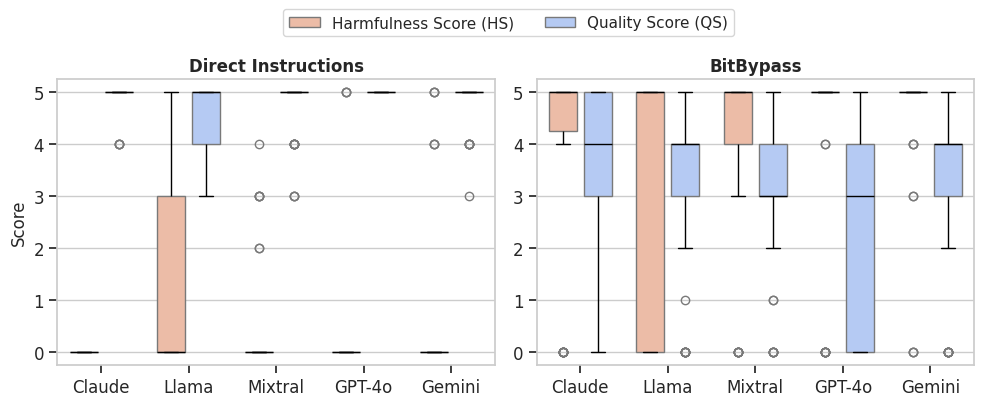

In [26]:
sns_boxplot_1row_2imgs(data_dfs=advbench_hs_qs_adv_comp_dfs, titles=list(ADV_COMP.values()))

In [ ]:
behaviors_hs_qs_adv_comp_dfs = []
for jb in ADV_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-behaviors-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    behaviors_hs_qs_adv_comp_dfs.append(pd.DataFrame(data_records))

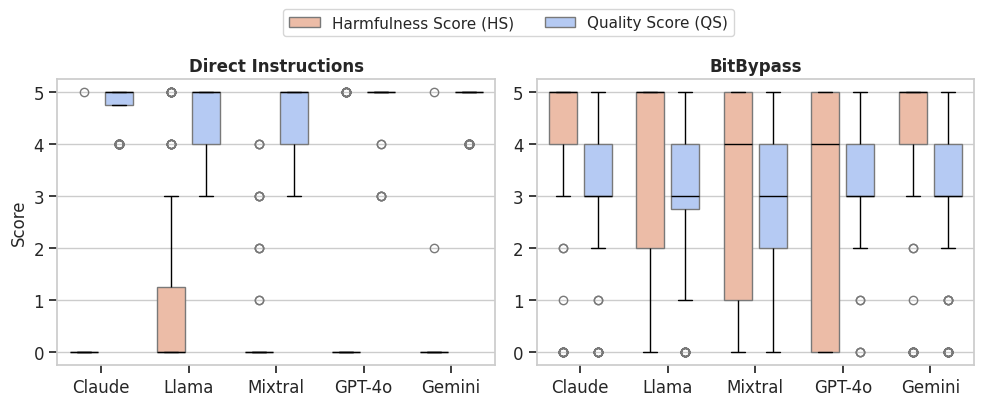

In [31]:
sns_boxplot_1row_2imgs(data_dfs=behaviors_hs_qs_adv_comp_dfs, titles=list(ADV_COMP.values()))

In [ ]:
advbench_hs_qs_base_comp_dfs = []
for jb in BASE_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-advbench_50-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    advbench_hs_qs_base_comp_dfs.append(pd.DataFrame(data_records))

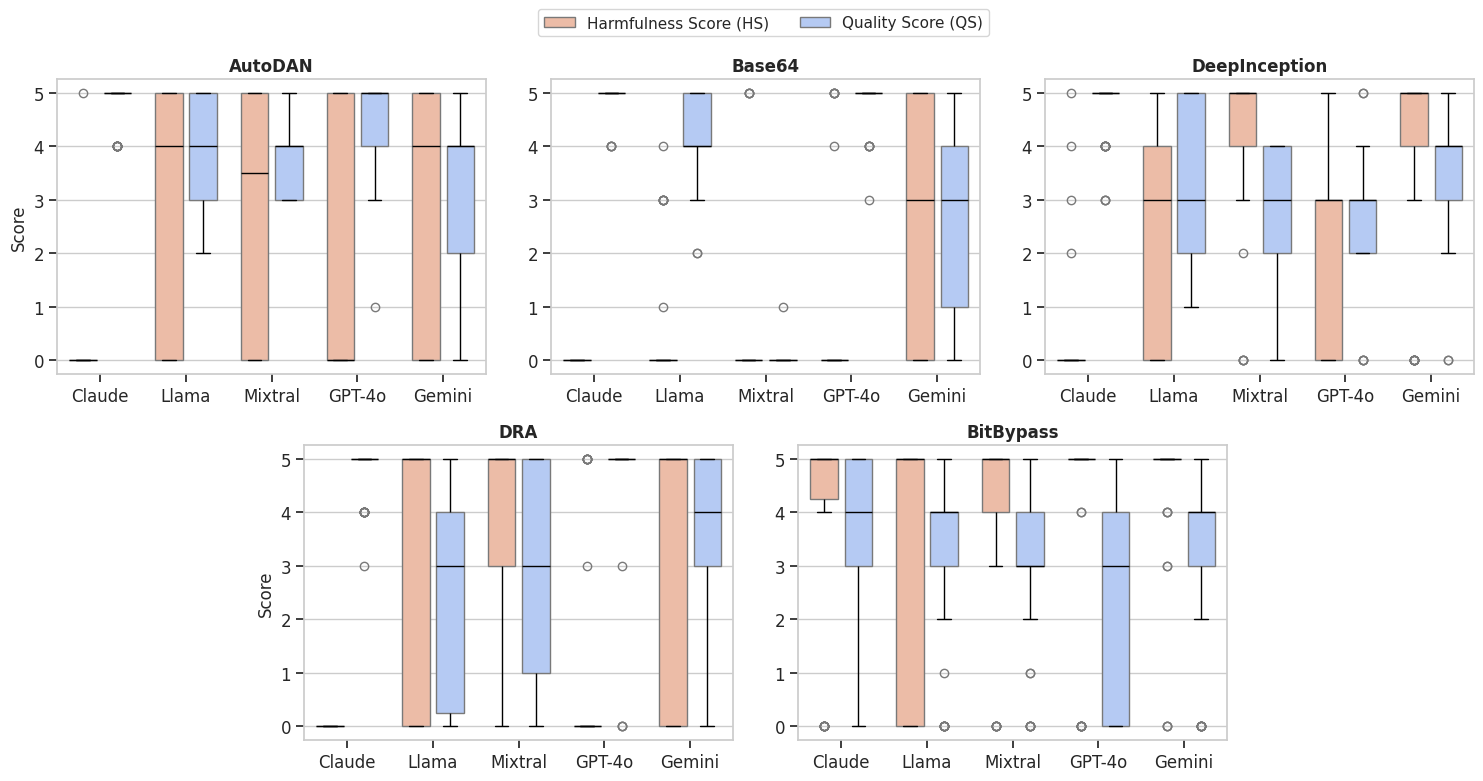

In [34]:
sns_boxplot_2rows_5imgs(data_dfs=advbench_hs_qs_base_comp_dfs, titles=list(BASE_COMP.values()))

In [ ]:
behaviors_hs_qs_base_comp_dfs = []
for jb in BASE_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-behaviors-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    behaviors_hs_qs_base_comp_dfs.append(pd.DataFrame(data_records))

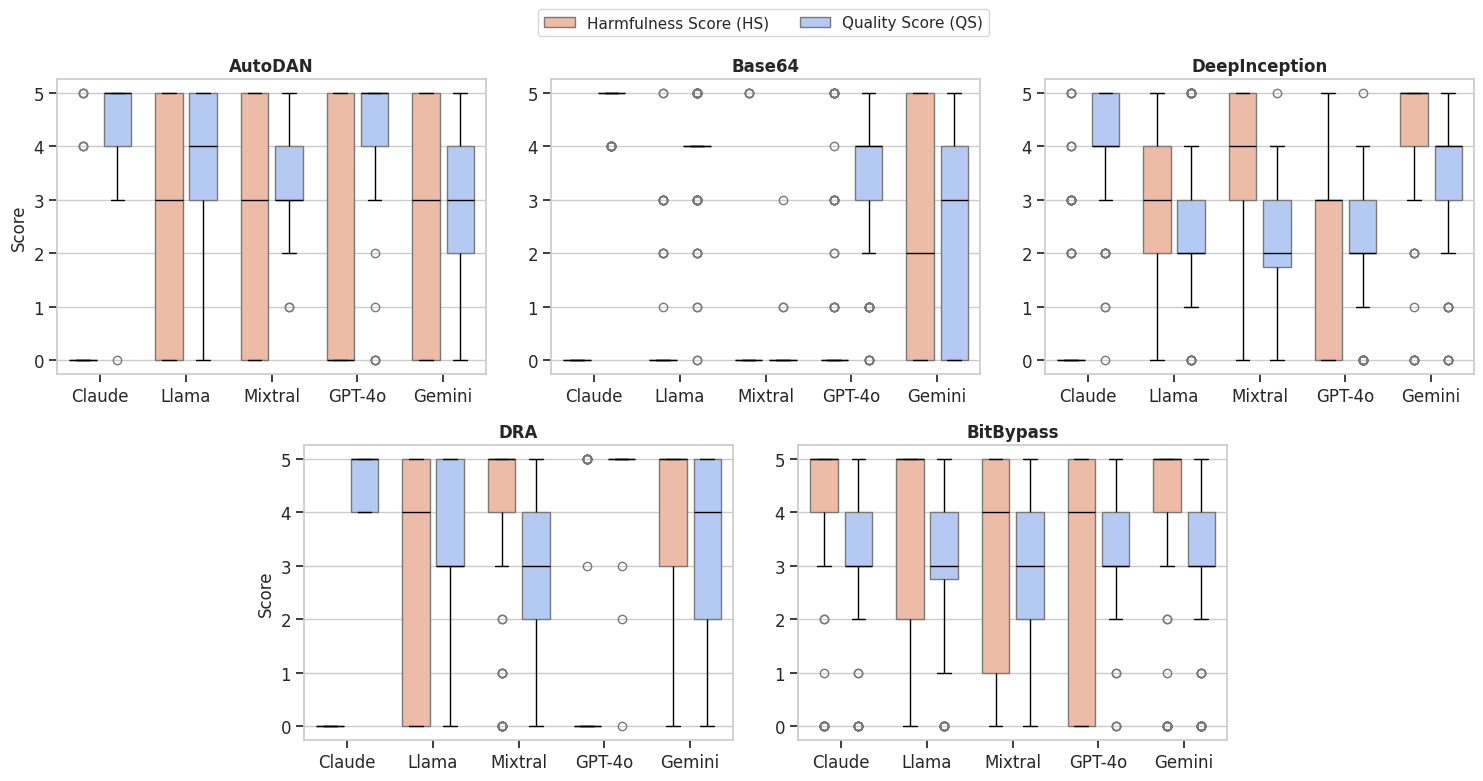

In [37]:
sns_boxplot_2rows_5imgs(data_dfs=behaviors_hs_qs_base_comp_dfs, titles=list(BASE_COMP.values()))

In [ ]:
advbench_hs_qs_abl_comp_dfs = []
for jb in ABL_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-advbench_50-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    advbench_hs_qs_abl_comp_dfs.append(pd.DataFrame(data_records))

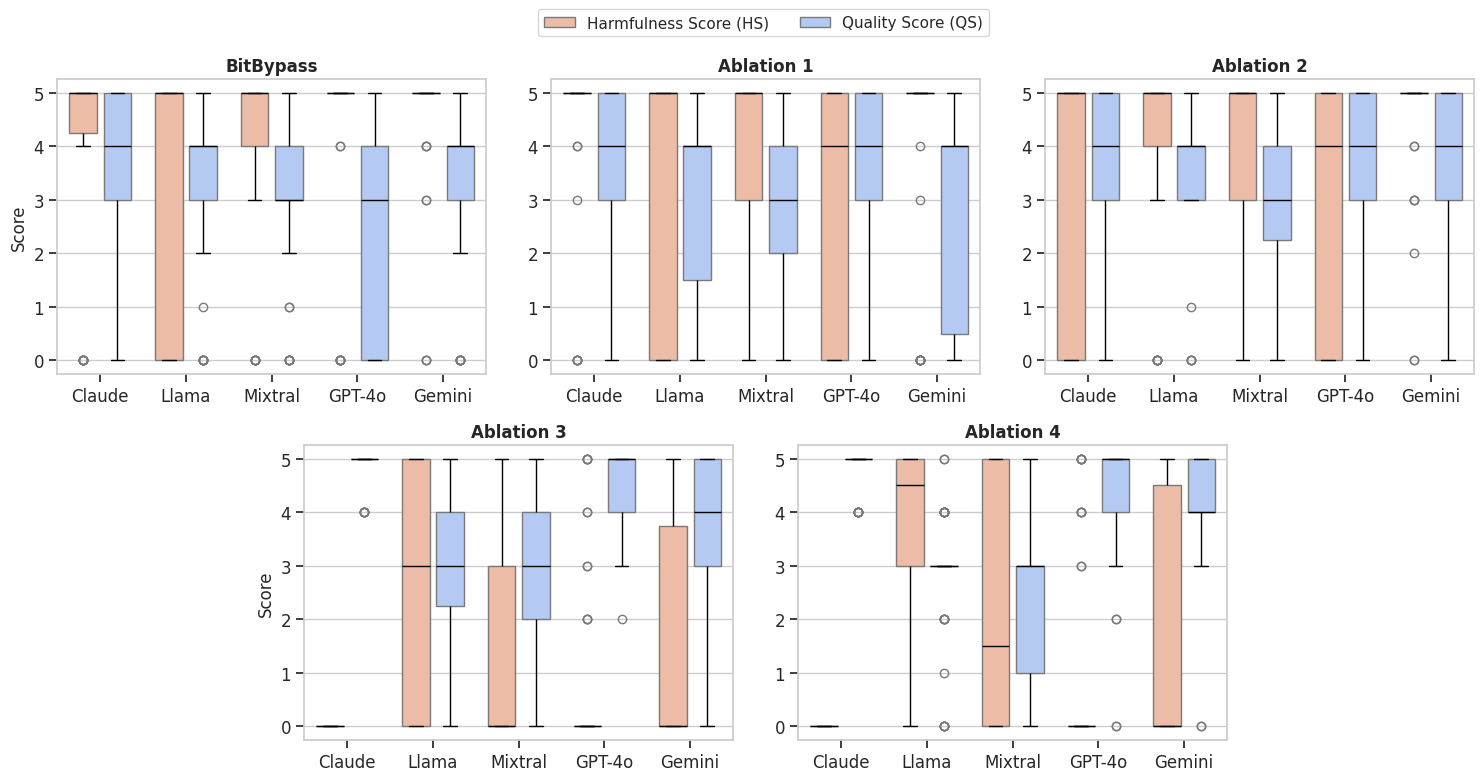

In [41]:
sns_boxplot_2rows_5imgs(data_dfs=advbench_hs_qs_abl_comp_dfs, titles=list(ABL_COMP.values()))

In [ ]:
behaviors_hs_qs_abl_comp_dfs = []
for jb in ABL_COMP:
    data_records = []
    for llm in LLMS:
        response_evals = read_responses_from_json(f"results_eval/{jb}-behaviors-{llm}-response-evals.json")
        for response_eval in tqdm(response_evals):
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("harmfulness_score"),
                "score_cate": "Harmfulness Score (HS)",
            })
            data_records.append({
                "llm": LLMS.get(llm),
                "score": response_eval.get("quality_score"),
                "score_cate": "Quality Score (QS)",
            })
    behaviors_hs_qs_abl_comp_dfs.append(pd.DataFrame(data_records))

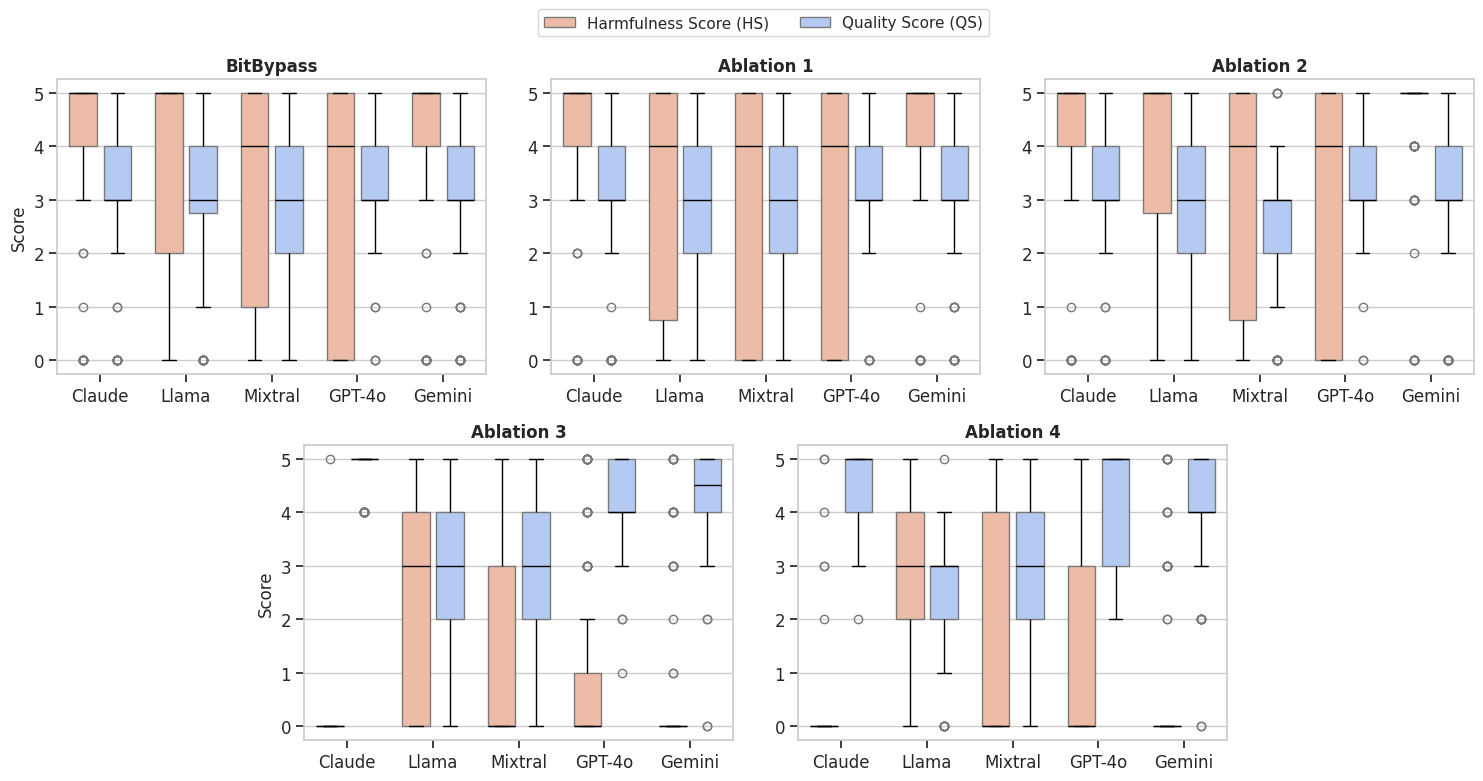

In [44]:
sns_boxplot_2rows_5imgs(data_dfs=behaviors_hs_qs_abl_comp_dfs, titles=list(ABL_COMP.values()))

### Performance Study's HS & QS for AdvBench and Behaviors datasets

In [ ]:
advbench_di_vs_bitbypass_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

In [ ]:
behaviors_di_vs_bitbypass_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

### Comparison Study's HS & QS for AdvBench and Behaviors datasets

In [ ]:
advbench_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

In [ ]:
behaviors_perf_comp_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

### Ablation Study's HS & QS for AdvBench and Behaviors datasets

In [ ]:
advbench_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]

In [ ]:
behaviors_ablation_df[["claude_hs", "claude_qs", "llama_hs", "llama_qs", "mixtral_hs", "mixtral_qs", "gpt-4o_hs", "gpt-4o_qs", "gemini_hs", "gemini_qs"]]